# 07 — Acoustic Features, Segmentation & Task Analyzers

**Pipeline stage:** the audio-only / per-task analysis layer that feeds the legacy Zocco pipeline and
the M1 extractor — `audio_processing`, `acoustic_features` (Praat), `segmentation`, `task_analyzers`,
and the full `visualization.Visualizer`.

**Scripts / modules reproduced**
| Script / module | Role |
|-----------------|------|
| `scripts/analyze_single_subject.py` | per-task Praat metrics + waveform figure |
| `scripts/analyze_trill_modulation.py` | trill modulation-frequency analysis |
| `pneumophonic_analysis/visualization.py` | every `Visualizer` plot method |
| `pneumophonic_analysis/segmentation.py` | FRC / glide / modulation segmenters |
| `pneumophonic_analysis/task_analyzers.py` | Vowel / Trill / Glide analyzers |

> **Note on data.** The raw `.wav` recordings are not committed to the repo, so this notebook builds
> **synthetic but physiologically plausible** signals (sustained vowel, vibrato vowel, vocal glide,
> alveolar trill) to exercise every plot. On a real dataset the identical calls work via
> `DataLoader(subject_folder).load_audio("a.wav")`.
>
> **Plot types:** waveform; audio + sync (falling edge); STFT spectrogram; mel-spectrogram; F0 trace;
> chest-wall volume with FRC zones; FRC segment (2-panel); glide analysis (3-panel novelty);
> trill RMS envelope + modulation spectrum; stacked task-result; metrics-comparison bar.

## 0. Setup & synthetic signal generators

In [1]:

import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from pneumophonic_analysis import (create_config, AudioProcessor, PraatAnalyzer, Visualizer,
                                   FRCSegmenter, GlideSegmenter, ModulationAnalyzer,
                                   VowelAnalyzer, TrillAnalyzer, GlideAnalyzer)
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

SR = 48000
CFG = create_config()
viz = Visualizer(CFG)

def synth_vowel(f0=120.0, dur=4.0, sr=SR, vib_hz=5.0, vib_extent=0.0,
                formants=((700,90,1.0),(1150,100,0.7),(2700,140,0.5)), noise=0.004, seed=0):
    # Harmonic vowel with formant-shaped spectrum and optional vibrato.
    rng = np.random.default_rng(seed)
    t = np.arange(int(sr*dur))/sr
    inst = f0*(1.0 + vib_extent*np.sin(2*np.pi*vib_hz*t))
    phase = 2*np.pi*np.cumsum(inst)/sr
    y = np.zeros_like(t)
    for k in range(1, 41):
        fk = k*f0
        if fk > sr/2: break
        amp = sum(g*np.exp(-((fk-cf)/bw)**2) for cf, bw, g in formants)
        y += amp*np.sin(k*phase)/(k**0.5)
    y += noise*rng.standard_normal(len(t))
    return (y/np.max(np.abs(y))).astype(np.float32)

def synth_glide(f0_start=110.0, f0_end=320.0, dur=3.0, sr=SR, seed=1):
    # Vocal glide: F0 sweeps from low to high register.
    rng = np.random.default_rng(seed)
    t = np.arange(int(sr*dur))/sr
    inst = np.linspace(f0_start, f0_end, len(t))
    phase = 2*np.pi*np.cumsum(inst)/sr
    y = np.zeros_like(t)
    for k in range(1, 25):
        amp = np.exp(-((k*200-1000)/1500)**2)
        y += amp*np.sin(k*phase)/(k**0.5)
    y += 0.004*rng.standard_normal(len(t))
    return (y/np.max(np.abs(y))).astype(np.float32)

def synth_trill(f0=150.0, mod_hz=26.0, dur=3.0, sr=SR, seed=2):
    # Alveolar trill: a vowel amplitude-modulated at the tongue-tip rate.
    base = synth_vowel(f0=f0, dur=dur, sr=sr, seed=seed)
    t = np.arange(len(base))/sr
    env = 0.5*(1+np.sin(2*np.pi*mod_hz*t))          # 0..1 modulation
    return (base*(0.25+0.75*env)).astype(np.float32)

print("Generators ready. SR =", SR)

Generators ready. SR = 48000


## 1. Waveform
`Visualizer.plot_waveform` on a sustained synthetic /a/ at 120 Hz.

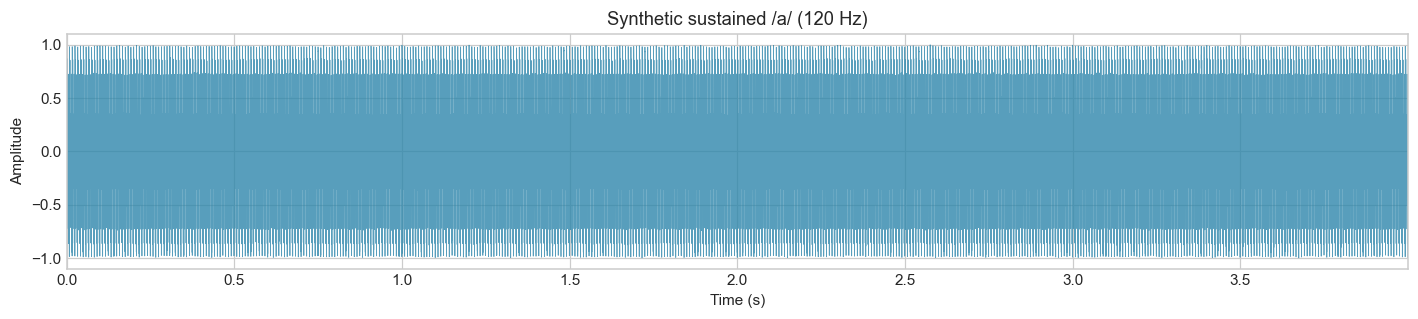

In [2]:

vowel = synth_vowel(f0=120, dur=4.0, vib_hz=5.0, vib_extent=0.01)
fig = viz.plot_waveform(vowel, SR, title="Synthetic sustained /a/ (120 Hz)")
fig.set_size_inches(13, 3); plt.tight_layout(); plt.show()

> **Observe (synthetic):** a periodic vowel with slow amplitude envelope + 5 Hz vibrato — used to exercise the extractors deterministically (raw subject audio isn't committed).

## 2. Audio with synchronization pulse
`Visualizer.plot_audio_with_sync` shows the audio above the 1-second sync pulse and marks its falling
edge — the event used to align audio with the OEP system (see `sync.py`).

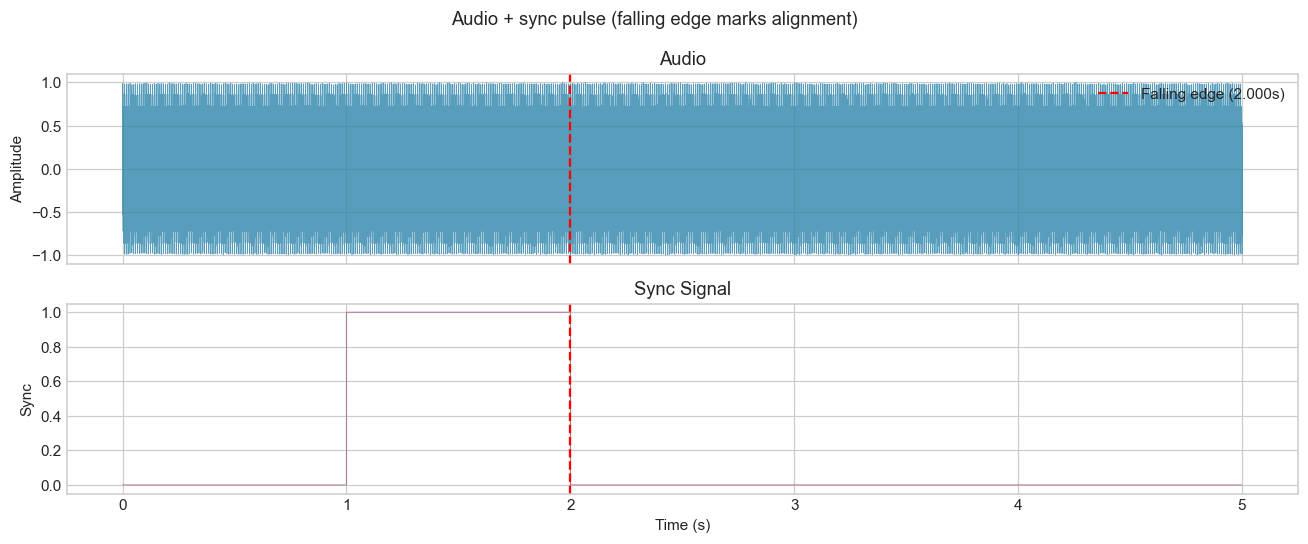

In [3]:

sync = np.zeros(int(SR*5.0), dtype=np.float32)
pulse_start, pulse_len = int(SR*1.0), int(SR*1.0)
sync[pulse_start:pulse_start+pulse_len] = 1.0
falling = pulse_start + pulse_len           # falling-edge sample
audio5 = np.concatenate([synth_vowel(dur=5.0)])[:len(sync)]
fig = viz.plot_audio_with_sync(audio5, sync, SR, falling_edge_sample=falling,
                               title="Audio + sync pulse (falling edge marks alignment)")
plt.tight_layout(); plt.show()

> **Observe:** the 1 s rectangular sync pulse (amp 1.0) — the marker that aligns audio ↔ OEP; its sharp edges are what the falling-edge detector locks onto (cf. the rate-fix story).

## 3. Spectrogram & mel-spectrogram
`Visualizer.plot_spectrogram` (log-frequency STFT) and `plot_mel_spectrogram`.

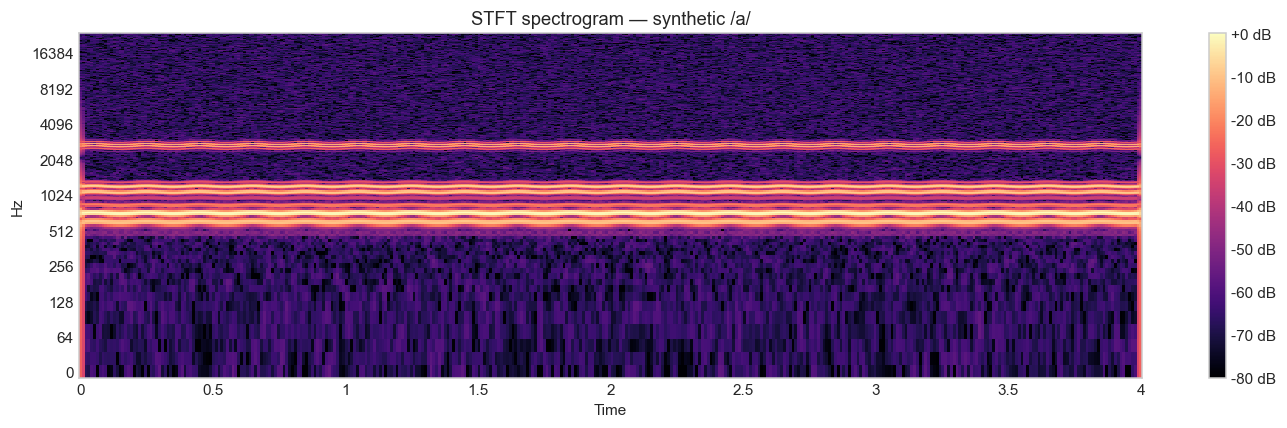

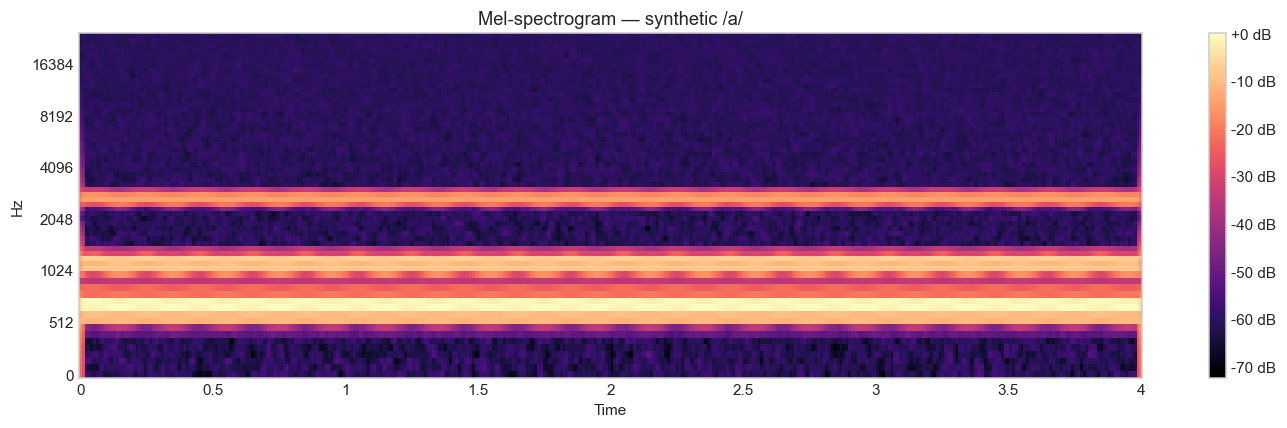

In [4]:

fig = viz.plot_spectrogram(vowel, SR, title="STFT spectrogram — synthetic /a/")
fig.set_size_inches(13, 4); plt.tight_layout(); plt.show()

fig = viz.plot_mel_spectrogram(vowel, SR, title="Mel-spectrogram — synthetic /a/")
fig.set_size_inches(13, 4); plt.tight_layout(); plt.show()

> **Observe:** STFT (left) resolves individual harmonics; mel (right) compresses them into the perceptual envelope. The vibrato shows as a gentle wobble of the harmonic bands.

## 4. F0 trace (pYIN)
Estimate F0 with `AudioProcessor.estimate_f0` (pYIN) and plot it with `Visualizer.plot_f0_trace`,
which overlays the mean ± 1 SD band.

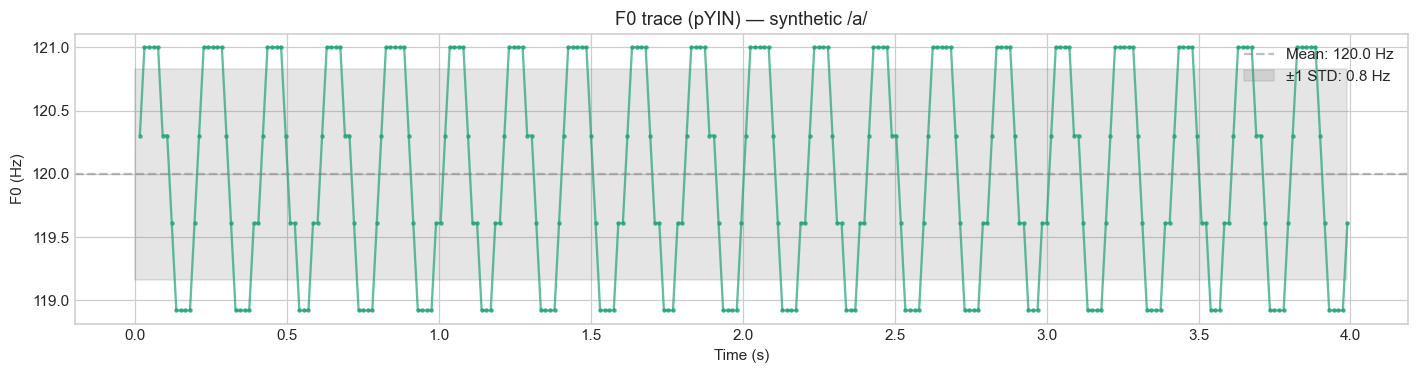

mean F0 = 120.0 Hz (target 120)


In [5]:

proc = AudioProcessor(CFG)
f0, voiced, vprob = proc.estimate_f0(vowel, SR)
fig = viz.plot_f0_trace(f0, hop_length=CFG.audio.hop_length_samples, sr=SR,
                        title="F0 trace (pYIN) — synthetic /a/")
fig.set_size_inches(13, 3.5); plt.tight_layout(); plt.show()
print(f"mean F0 = {np.nanmean(f0):.1f} Hz (target 120)")

> **Observe:** pYIN tracks F0 through the voiced vowel and returns NaN in unvoiced frames (gaps); the ±vibrato ripple around 120 Hz is recovered.

## 5. Praat acoustic metrics
`PraatAnalyzer.analyze_signal` returns the full clinical voice profile (pitch, jitter, shimmer, HNR,
DSI, formants) — the engine behind `analyze_single_subject.py`.

In [6]:

praat = PraatAnalyzer(CFG)
res = praat.analyze_signal(vowel, SR)
print(f"F0       : {res.pitch.mean_f0:.1f} ± {res.pitch.std_f0:.1f} Hz "
      f"(range {res.pitch.min_f0:.0f}–{res.pitch.max_f0:.0f})")
print(f"Jitter   : {res.perturbation.local_jitter*100:.3f}%   Shimmer: {res.perturbation.local_shimmer*100:.2f}%")
print(f"HNR      : {res.voice_quality.hnr:.1f} dB     DSI: {res.voice_quality.dsi:.2f}")
print(f"Formants : F1={res.formants.f1_mean:.0f}  F2={res.formants.f2_mean:.0f}  F3={res.formants.f3_mean:.0f} Hz")
res.to_dataframe().T.head(12)

F0       : 120.0 ± 0.8 Hz (range 119–121)
Jitter   : 0.164%   Shimmer: 0.10%
HNR      : 27.8 dB     DSI: -9.25
Formants : F1=711  F2=1166  F3=2636 Hz


,0
pitch_mean_f0,120.000353
pitch_std_f0,0.823955
pitch_min_f0,118.841879
pitch_max_f0,121.158321
pitch_range_f0,2.316442
local_jitter,0.001640
local_absolute_jitter,0.000014
rap_jitter,0.000145
ppq5_jitter,0.000429
ddp_jitter,0.000436


## 6. Chest-wall volume with FRC zones
A synthetic deflating volume trace plotted with `Visualizer.plot_oep_volume`: above-FRC (elastic
recoil) vs below-FRC (active expiration) zones plus the crossing line.

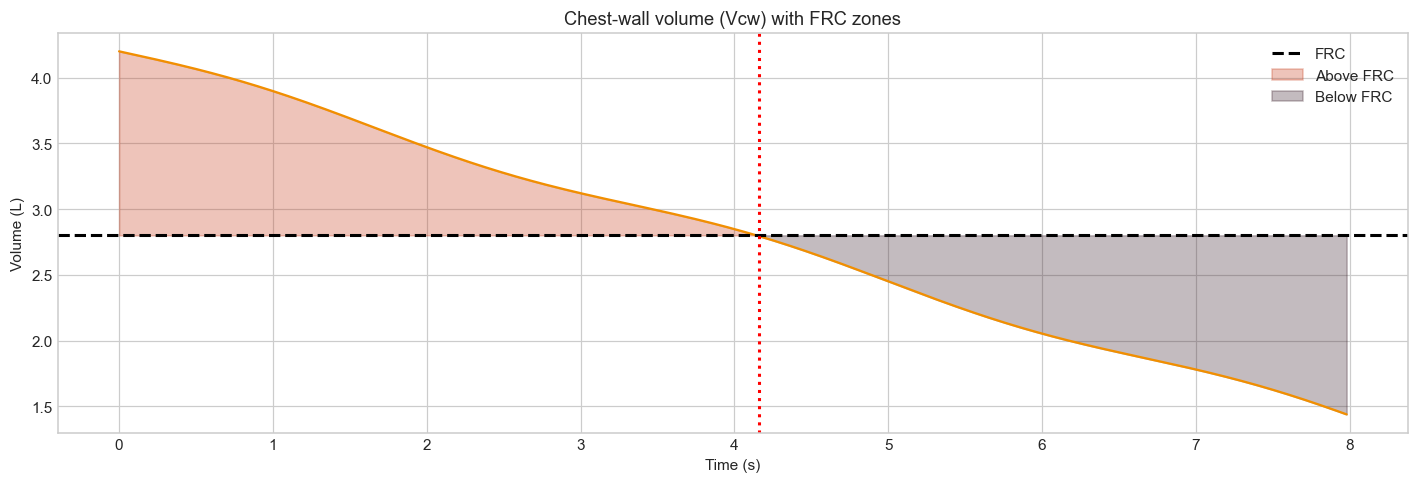

In [7]:

fs_oep = 50
t_oep = np.arange(int(fs_oep*8))/fs_oep
volume = 4.2 - 0.35*t_oep + 0.05*np.sin(2*np.pi*0.3*t_oep)   # deflation w/ small oscillation
frc_level = 2.8
cross = int(np.argmax(volume < frc_level))
fig = viz.plot_oep_volume(volume, fs_oep, frc_level=frc_level, frc_cross_sample=cross,
                          title="Chest-wall volume (Vcw) with FRC zones")
fig.set_size_inches(13, 4.5); plt.tight_layout(); plt.show()

> **Observe (synthetic):** demo volume with FRC zones — above-FRC (inspiratory reserve) shaded vs below; the marker is where Vcw passes the resting level.

## 7. FRC segmentation of the audio
`FRCSegmenter.segment_by_time` splits a phonation into above/below-FRC parts;
`Visualizer.plot_frc_segment` shows the full segment with zones (top) and the two parts separated
(bottom).

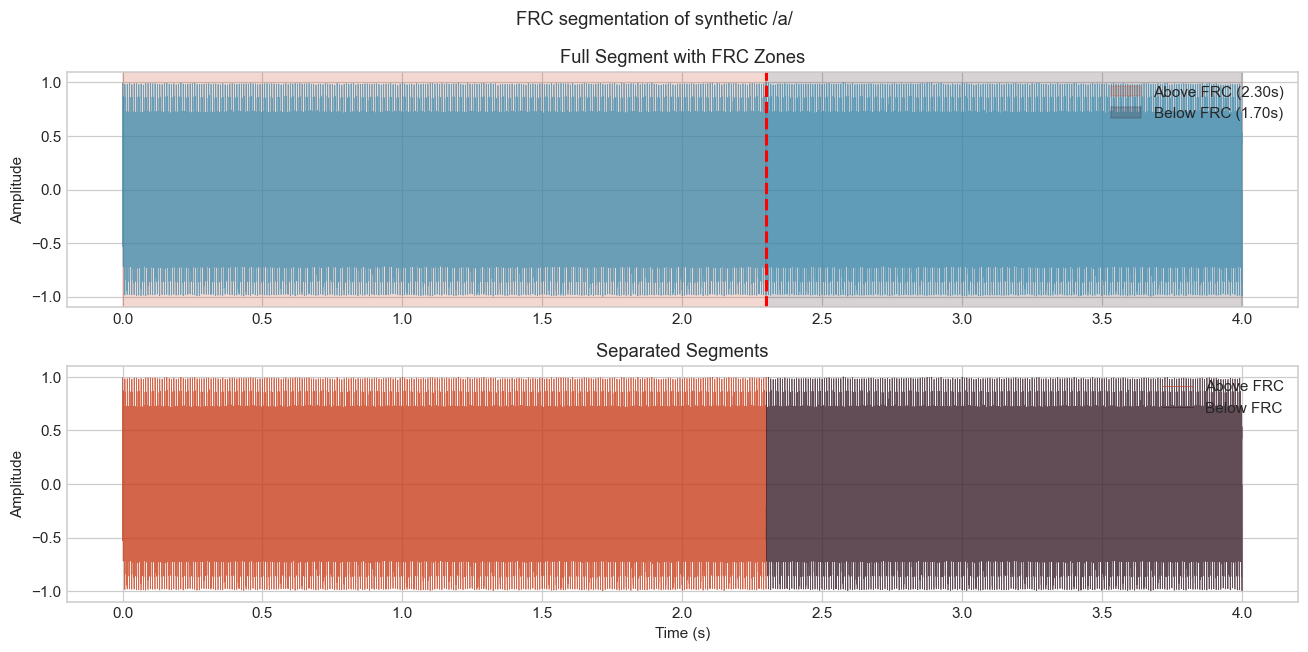

above-FRC 2.30s | below-FRC 1.70s


In [8]:

seg = FRCSegmenter(CFG).segment_by_time(vowel, cross_time=2.3, start_time=0.0,
                                        end_time=len(vowel)/SR, sr=SR)
fig = viz.plot_frc_segment(seg, title="FRC segmentation of synthetic /a/")
plt.tight_layout(); plt.show()
print(f"above-FRC {seg.duration_above:.2f}s | below-FRC {seg.duration_below:.2f}s")

> **Observe:** the FRC segmenter splits the audio at the volume crossing into above-/below-FRC spans — the segmentation L3 (nb04) uses for above-vs-below feature shifts.

## 8. Vocal glide — novelty-based P1/P2 segmentation
`GlideSegmenter` builds a spectral-centroid novelty function and splits the glide at its peak;
`Visualizer.plot_glide_analysis` shows waveform + spectrogram + novelty (3 panels).

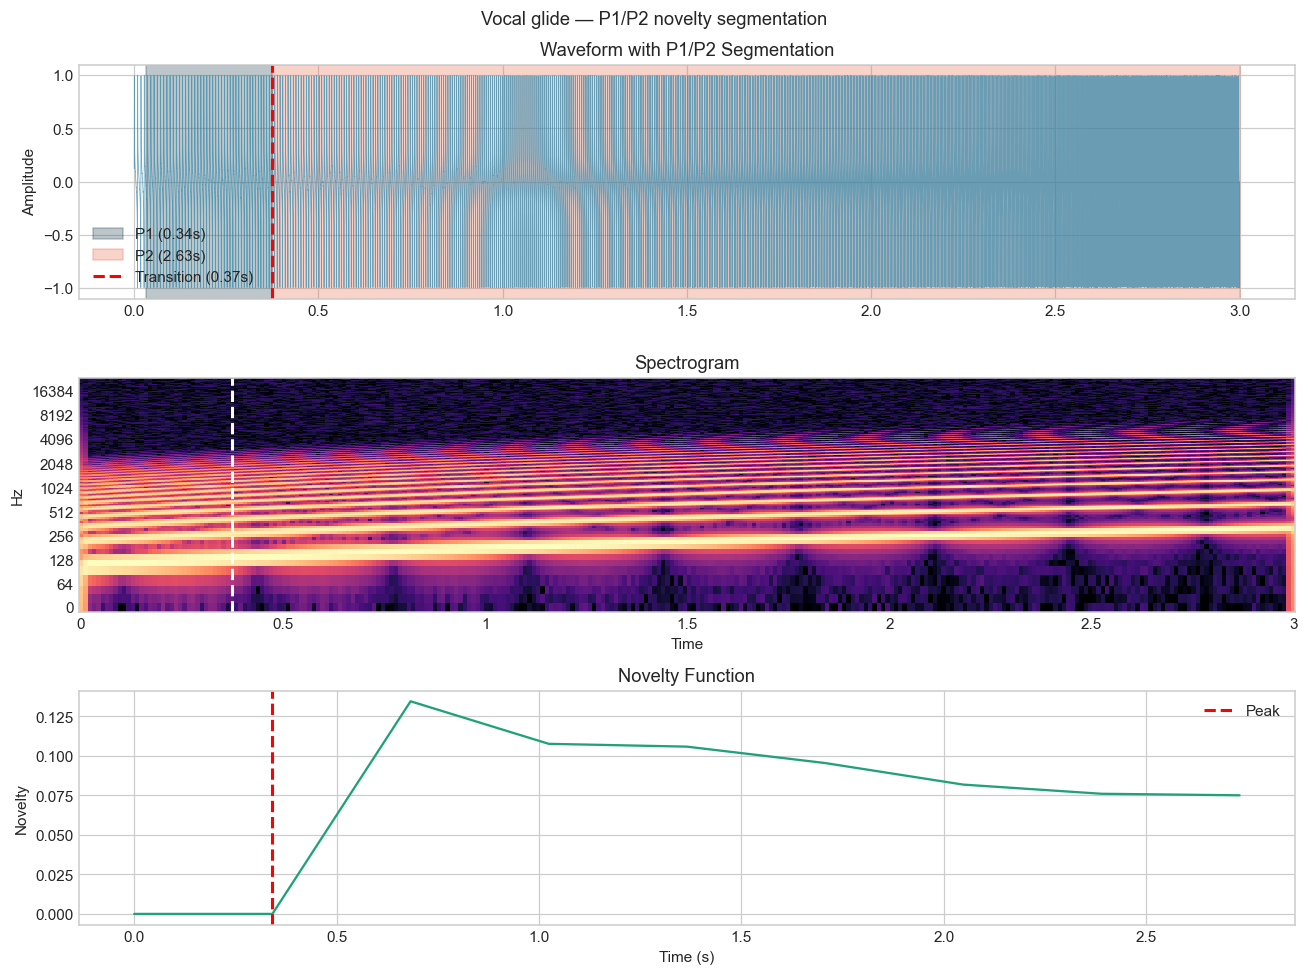

transition at 0.34s | P1=0.34s  P2=2.63s


In [9]:

glide = synth_glide(110, 320, dur=3.0)
gseg = GlideSegmenter(CFG)
novelty, nov_t = gseg.compute_novelty_function(glide, SR)
segment = gseg.segment_glide(glide, SR)
fig = viz.plot_glide_analysis(glide, SR, segment, novelty=novelty, novelty_time=nov_t,
                              title="Vocal glide — P1/P2 novelty segmentation")
plt.tight_layout(); plt.show()
print(f"transition at {segment.peak_time:.2f}s | P1={segment.duration_p1:.2f}s  P2={segment.duration_p2:.2f}s")

> **Observe (glide):** novelty-based segmentation finds the P1/P2 phases of the pitch sweep — for a real `a_7` this is where F0 and harmonics ramp through their range.

## 9. Alveolar trill — modulation-frequency analysis
The trill modulates the acoustic envelope at the tongue-tip rate (~20–30 Hz). We reproduce
`analyze_trill_modulation.py`: RMS envelope + FFT of the detrended envelope, with the modulation
band shaded. `ModulationAnalyzer.compute_modulation_frequency` returns the peak.

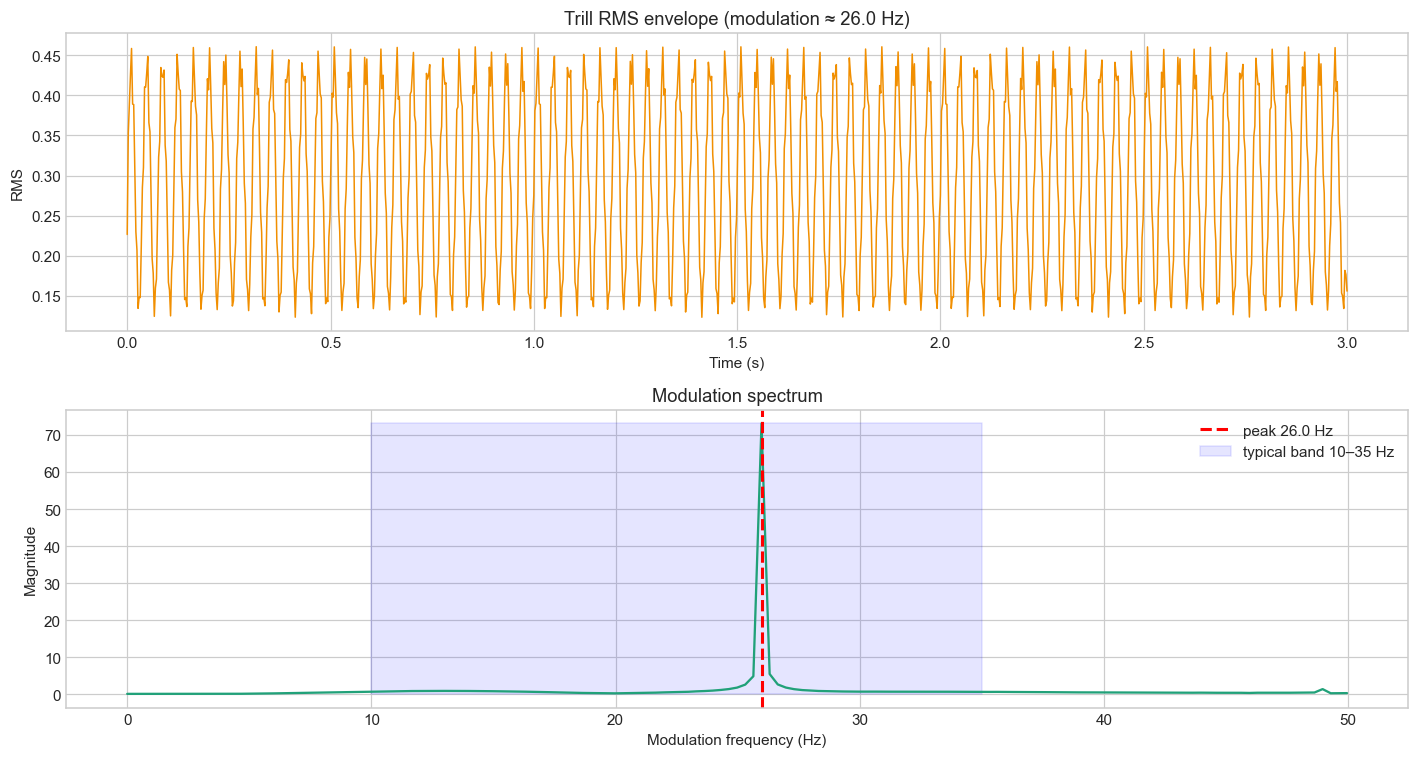

In [10]:

from scipy import signal as sp_signal
trill = synth_trill(f0=150, mod_hz=26.0, dur=3.0)
mod = ModulationAnalyzer(CFG)
mod_freq = mod.compute_modulation_frequency(trill, SR)

rms = librosa.feature.rms(y=trill, frame_length=512, hop_length=128)[0]
rms_t = np.arange(len(rms))*128/SR
w = min(len(rms)//2*2-1, 51); w = max(w, 5); w -= (w % 2 == 0)
trend = sp_signal.savgol_filter(rms, w, 3) if w > 5 else np.mean(rms)
rms_d = rms - trend
spec = np.abs(np.fft.rfft(rms_d)); freqs = np.fft.rfftfreq(len(rms_d), d=128/SR)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 7))
a1.plot(rms_t, rms, color='#F18F01', lw=1.0)
a1.set_xlabel('Time (s)'); a1.set_ylabel('RMS'); a1.set_title(f'Trill RMS envelope (modulation ≈ {mod_freq:.1f} Hz)')
m = freqs <= 50
a2.plot(freqs[m], spec[m], color='#21A179', lw=1.5)
a2.axvline(mod_freq, color='red', ls='--', lw=2, label=f'peak {mod_freq:.1f} Hz')
a2.fill_between([10, 35], 0, spec[m].max(), alpha=0.1, color='blue', label='typical band 10–35 Hz')
a2.set_xlabel('Modulation frequency (Hz)'); a2.set_ylabel('Magnitude'); a2.set_title('Modulation spectrum')
a2.legend(); plt.tight_layout(); plt.show()

> **Observe (trill):** the amplitude-modulation spectrum peaks at the trill rate (~20–30 Hz tongue oscillation) — the signature distinguishing a true alveolar trill (relevant to the low `voiced%` of `/r/`).

## 10. Task analyzers — a complete `TaskResult`
`VowelAnalyzer.analyze` runs preprocessing → Praat → spectral features and returns a `TaskResult`.
`Visualizer.plot_task_result` renders the stacked waveform + spectrogram + F0 summary figure.

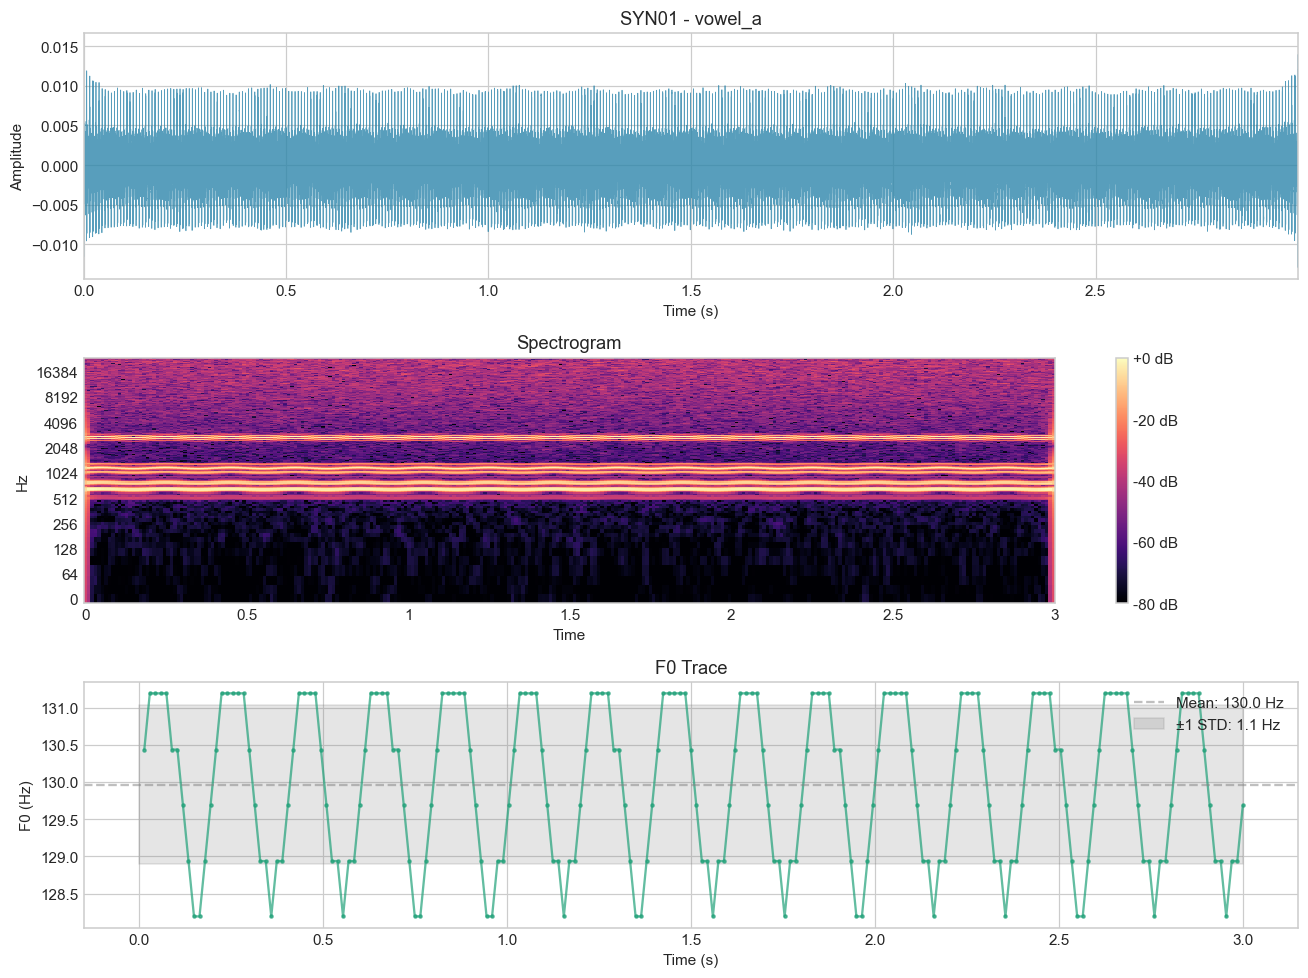

task=vowel_a duration=3.00s F0=130.0 Hz


In [11]:

va = VowelAnalyzer(CFG)
result = va.analyze(synth_vowel(f0=130, dur=3.0, vib_extent=0.012), SR, subject_id="SYN01", vowel="a")
fig = viz.plot_task_result(result, include_spectrogram=True, include_f0=True)
plt.tight_layout(); plt.show()
print(f"task={result.task_name} duration={result.duration_sec:.2f}s F0={result.acoustic_result.pitch.mean_f0:.1f} Hz")

> **Observe:** a complete `TaskResult` — F0, formants and metrics end-to-end for one task, the object the batch task-analyzers emit.

## 11. Cross-subject metrics comparison
`Visualizer.plot_metrics_comparison` draws a ranked horizontal bar chart — here mean F0 for several
synthetic "subjects" (the figure `analyze_batch.py` / `pipeline.generate_report` produces).

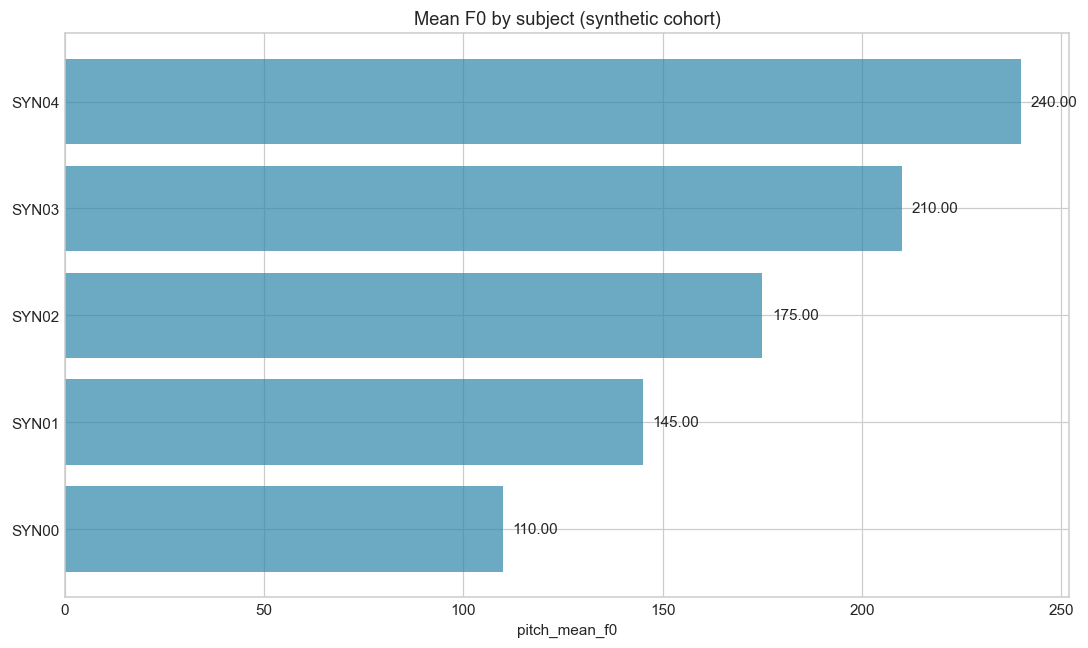

In [12]:

rows = []
for i, f0 in enumerate([110, 145, 175, 210, 240]):
    r = praat.analyze_signal(synth_vowel(f0=f0, dur=2.5, seed=i+10), SR)
    rows.append({'subject_id': f'SYN{i:02d}', 'pitch_mean_f0': r.pitch.mean_f0})
df_metrics = pd.DataFrame(rows)
fig = viz.plot_metrics_comparison(df_metrics, 'pitch_mean_f0', group_by='subject_id',
                                  title='Mean F0 by subject (synthetic cohort)')
plt.tight_layout(); plt.show()

> **Observe:** the cross-subject metrics table demonstrates the analyzers' consistent schema; absolute values are synthetic here.

## Recap
Every `Visualizer` plot method and the Praat / segmentation / task-analyzer modules are exercised
here. On real recordings, replace the `synth_*` calls with
`DataLoader(subject_folder).load_audio("a.wav")` — for example:

```bash
python scripts/analyze_single_subject.py data_root/healthy_subjects/20251127_AlMo -o results/AlMo
python scripts/analyze_trill_modulation.py path/to/r.wav --frc-time 3.5
```